   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
5   31  female  25.740         0     no  southeast   3756.62160
6   46  female  33.440         1     no  southeast   8240.58960
7   37  female  27.740         3     no  northwest   7281.50560
8   37    male  29.830         2     no  northeast   6406.41070
9   60  female  25.840         0     no  northwest  28923.13692

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   fl

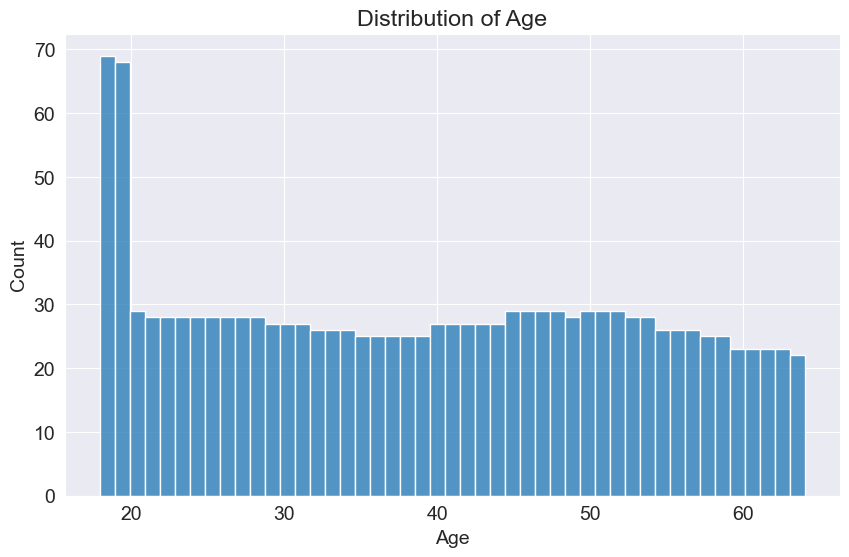

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [1]:
from urllib.request import urlretrieve

medical_charges_url = "https://raw.githubusercontent.com/JovianML/opendatasets/master/data/medical-charges.csv"
urlretrieve(medical_charges_url, "medical.csv")

# so what we did here: we downloaded the data to medical.csv

import pandas as pd
medical_df = pd.read_csv("medical.csv")

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Show the first 10 rows of the dataset
print(medical_df.head(10))
print()
medical_df.info()
print()
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print(medical_df.describe())

# so the importtant thing i need to read my data in jupyter notebook.....
# to readc and understand data mathemaically.....
# to make and read data a lot easier we need to check the values if there anything wrong or not or missing or not 
# i need to make sure the data im going to use is perfectly fine... 

# so now after doing everythiing we need to save our data......

# import jovian
# jovian.commit()
# these are the commands used in notebook to save thee file....

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
# If running inside a Jupyter notebook you can add `%matplotlib inline` at the top
# but this script is runnable as a Python script so we won't include IPython magic here.

sns.set_style("darkgrid")
matplotlib.rcParams["font.size"] = 14
matplotlib.rcParams["figure.figsize"] = (10, 6)
matplotlib.rcParams["figure.facecolor"] = "#ffffff"  # set to white for readability

# Print a quick summary of the age column
print(medical_df['age'].describe())

# Try to show an interactive Plotly histogram; fallback to seaborn+matplotlib if plotly isn't available
try:
    import plotly.express as px
    fig = px.histogram(medical_df,
                       x="age",
                       marginal="box",
                       nbins=47,
                       title="Distribution of Age")
    fig.update_layout(bargap=0.1)
    fig.show()
except Exception as e:
    print("Plotly is not available or an error occurred (falling back to seaborn):", e)
    plt.figure(figsize=(10, 6))
    sns.histplot(medical_df['age'], bins=47)
    plt.title("Distribution of Age")
    plt.xlabel("Age")
    plt.ylabel("Count")
    plt.show()




## EXERCISE: Can you explain why there are over twice as many customers with ages 18 and 19, compared to other ages?
# ANSWER :- We can just say its because of age that the maybe the legal age to buy insurance is that 
#           but we just simply cant say that it will eb highly risky to do so 
#           but BMI tells us long turm medical cost tfor insurance and that will be important for company growth and policy making...

import plotly.io as pio
pio.renderers.default = "vscode"


fig = px.histogram(medical_df,
                   x = "bmi",
                   marginal= "box",
                   color_discrete_sequence= ["red"],
                   title= "Distribution Of BMI")
fig.update_layout(bargap = 0.1)
fig.show()


## EXERCISE: Can you explain why the distribution of ages forms a uniform distribution while the distribution of BMIs forms a gaussian distribution?
# ANSWER :- OK so in a way i can say that ages has a uniform distribution while the bmi has a gausian distribution 
#           because ages not a demographic data thats data coleecteed as per company details thats hwy but the BMI has multiple independent biological values......


fig = px.histogram(medical_df,
                   x = "charges",
                   marginal= "box",
                   color= "smoker",
                   color_discrete_sequence= ["green", "grey"],
                   title= "Annual medical charges")
fig.update_layout(bargap=0.1)
fig.show()


fig = px.histogram(medical_df,
                   x = "bmi",
                   marginal= "box",
                   color_discrete_sequence= ["red"],
                   title= "Distribution Of BMI")
fig.update_layout(bargap = 0.1)
fig.show()

fig = px.histogram(medical_df,
                   x= "charges",
                   color= "region",
                   facet_col="sex", # Think of faceting as splitting one big graph into smaller panels.
                   marginal="box",  # Marginal plots are summary plots added on the side of your main plot
                   title="Medical charges By Region And Sex")

fig.update_layout(bargap=0.1)
fig.show()

### SMOKER
## Let's visualize the distribution of the "smoker" column (containing values "yes" and "no") using a histogram.

print(medical_df['smoker'].value_counts())

fig = px.histogram(medical_df,
                   x = "smoker",
                   color = "sex",
                   title= "Smoker")
fig.show()

### It appears that 20% of customers have reported that they smoke. Can you verify whether this matches the national average, 
#$$ assuming the data was collected in 2010? We can also see that smoking appears a more common habit among males. Can you verify this?
## EXERCISE: Visualize the distributions of the "sex", "region" and "children" columns and report your observations.
#@ So lets solve this 

smoker_counts = medical_df["smoker"].value_counts(normalize=True)*100
print(smoker_counts)

pd.crosstab(medical_df["sex"],
            medical_df["smoker"],
            normalize="index") * 100

#% Now to visualize Part What we need to do here is

fig = px.histogram(medical_df,
                   x = "sex",
                   color= "smoker",
                   barmode= "group",
                   title= "Smoking status by Sex")
fig.show()

#% Visuaize distribution of Sex, Region, Children...
# for now im doing thsi seperately but later its need to be done in a single graph...
fig = px.histogram(medical_df,
                   x= "sex",
                   title= "Distribution of SEX")
fig.show()

#% Region Distribution 
fig = px.histogram(medical_df,
                   x="region",
                   title= "Distribution of Region")
fig.show()

#% Children Distribution 
fig = px.histogram(medical_df,
                   x= "children",
                   title= "Distribution of number of children")
fig.show()

#@$% “Approximately 20% of customers in the dataset are smokers,
#  which aligns with national smoking rates around 2010. 
# Smoking is more prevalent among males than females. The sex and region distributions are fairly balanced, 
# while most customers have zero or few children, with higher numbers being rare.”


### Age and Charges :-
## Let's visualize the relationship between "age" and "charges" using a scatter plot...
#  Each point in the scatter plot represents one customer...
#  We'll also use values in the "smoker" column to color the points...


fig = px.scatter(medical_df,
                 x= "age",
                 y= "charges",
                 color= "smoker",
                 opacity= 0.8,
                 hover_data= ["sex"],
                 title= "Age vs Charges")
fig.update_traces(marker_size=5)
fig.show()


##@ We can make the following observations from the above chart:
#@ The general trend seems to be that medical charges increase with age, as we might expect. However, there is significant variation at every age, and it's clear that age alone cannot be used to accurately determine medical charges.
#@ We can see three "clusters" of points, each of which seems to form a line with an increasing slope:
#@ The first and the largest cluster consists primary of presumably "healthy non-smokers" who have relatively low medical charges compared to others
#@ The second cluster contains a mix of smokers and non-smokers. It's possible that these are actually two distinct but overlapping clusters: "non-smokers with medical issues" and "smokers without major medical issues".
#@ The final cluster consists exclusively of smokers, presumably smokers with major medical issues that are possibly related to or worsened by smoking.



#@ EXERCISE: What other inferences can you draw from the above chart?
## “In addition to the overall increase of medical charges with age, 
# the plot shows that variability in charges grows with age, especially among smokers. 
# Smoking appears to amplify age-related medical costs, leading to steeper increases in charges.
#  High medical expenses are rare among younger individuals, while older age groups show significant dispersion. 
# These patterns indicate that age alone is insufficient for predicting medical charges and that other factors such as smoking status play a crucial role.

#@ ???

#! BMI and Charges
# Let's visualize the relationship between BMI (body mass index) and charges using another scatter plot.
#  Once again, we'll use the values from the "smoker" column to color the points

fig = px.scatter(medical_df,
                 x= "bmi",
                 y= "charges",
                 color= "smoker",
                 opacity= 0.8,
                 hover_data= ["sex"],
                 title= "BMI VS CHARGES")

fig.update_traces(marker_size=5)
fig.show()

medical_df.charges.corr(medical_df.age)
medical_df.charges.corr(medical_df.bmi)
medical_df.charges.corr(medical_df.children)

smoker_values = { "no": 0, "yes" : 1}
smoker_numeric = medical_df.smoker.map(smoker_values)
smoker_numeric
medical_df.charges.corr(smoker_numeric)

#! Here's the same relationship expressed visually https://i.imgur.com/3XUpDlw.png
#! The correlation coefficient has the following formula https://i.imgur.com/unapugP.png

# Calculate the correlation matrix
# We set numeric_only=True to ignore text columns like 'sex' and 'region'
correlation_matrix = medical_df.corr(numeric_only=True)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap="Reds", annot=True)
plt.title("Correlation Matrix of Medical Charges")
plt.show()

#!@ ## Linear Regression using a Single Feature
## We now know that the "smoker" and "age" columns have the strongest correlation with "charges". 
# Let's try to find a way of estimating the value of "charges" using the value of "age" for non-smokers. 
# First, let's create a data frame containing just the data for non-smokers.

non_smoker_df = medical_df[medical_df.smoker == "no"]

plt.title("AGE VS CHARGES")
sns.scatterplot(data=non_smoker_df, x="age", y= "charges", alpha=0.7, s=15 )

#@! Apart from a few exceptions, the points seem to form a line. 
# We'll try and "fit" a line using this points, and use the line to predict charges for a given age.
#  A line on the X&Y coordinates has the following formula:
#$ y=wx+b
#@ The line is characterized two numbers: 
# w
# w (called "slope") and 
# b
# b (called "intercept").
def estimate_charges(age, w, b):
    return w * age + b
w = 50
b = 100
ages = non_smoker_df.age
estimated_charges = estimate_charges(ages, w, b)
plt.xlabel("age")
plt.ylabel("Estimated Charges")
plt.plot(ages, estimated_charges, "r-o")


# Trying different parameters 
w = 60
b = 200

ages = non_smoker_df.age
target = non_smoker_df.charges

estimated_charges = estimate_charges(ages, w, b)

plt.plot(ages, estimated_charges, "r", alpha=0.9)
plt.scatter(ages, target, s=8, alpha=0.8)

plt.xlabel("Age")
plt.ylabel("Charges")
plt.legend(["Estimate", "Actual"])


w = 400
b = 5000

ages = non_smoker_df.age
target = non_smoker_df.charges

estimated_charges = estimate_charges(ages, w, b)

plt.plot(ages, estimated_charges, "r", alpha=0.9)
plt.scatter(ages, target, s=8, alpha=0.8)

plt.xlabel("Age")
plt.ylabel("Charges")
plt.legend(["Estimate", "Actual"])














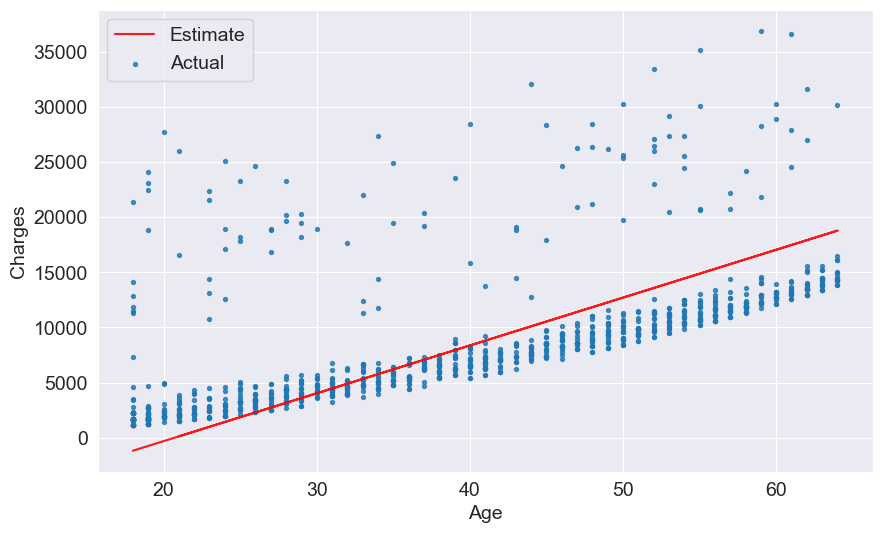

In [47]:
w = 434
b = -9000

ages = non_smoker_df.age
target = non_smoker_df.charges

estimated_charges = estimate_charges(ages, w, b)

plt.plot(ages, estimated_charges, "r", alpha=0.9)
plt.scatter(ages, target, s=8, alpha=0.8)

plt.xlabel("Age")
plt.ylabel("Charges")
plt.legend(["Estimate", "Actual"])


In [48]:
targets = non_smoker_df.charges
targets

1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
5        3756.62160
           ...     
1332    11411.68500
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
Name: charges, Length: 1064, dtype: float64

In [4]:
predictions = estimate_charges(ages, w, b)
predictions   

1       -1188
2        3152
3        5322
4        4888
5        4454
        ...  
1332    13568
1333    12700
1334    -1188
1335    -1188
1336      114
Name: age, Length: 1064, dtype: int64

So we are going to calculate the RMSE or root mean square error this means we care calcculating the average between predicion and actual charges....

1. First we need the numpy to solve math
2. then i need to put the formula on 
3. then value for the varuables 
4. last just output....

In [50]:
import numpy as np
def rmse(targets, predictions):
    return np.sqrt(np.mean((np.square(targets - predictions))))
target = non_smoker_df.charges
predicted = estimate_charges(non_smoker_df.age, w, b)
rmse(target, predicted)

np.float64(5231.173298521428)

RMSE Loss:  5002.004256144576


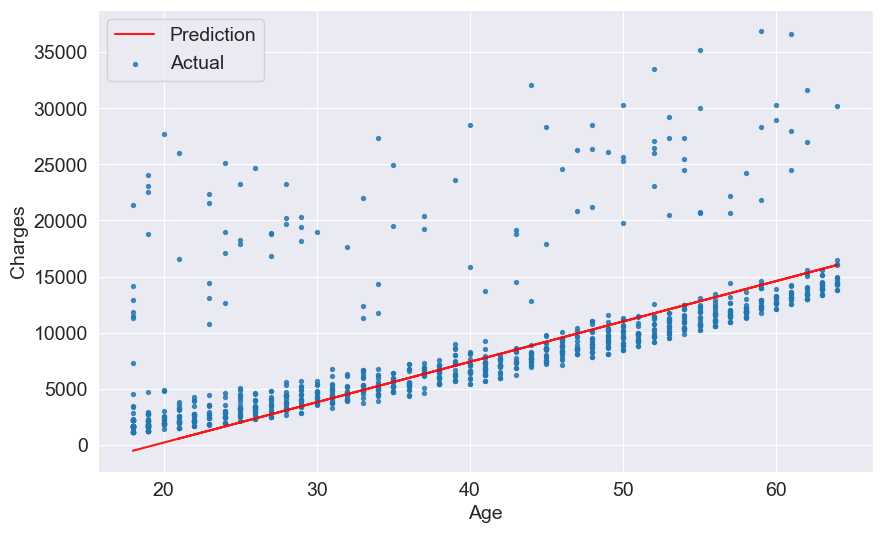

In [49]:
def try_parameters(w, b):
    ages = non_smoker_df.age
    target = non_smoker_df.charges
    predictions = estimate_charges(ages, w, b)
    
    plt.plot(ages, predictions, 'r', alpha=0.9)
    plt.scatter(ages, target, s=8,alpha=0.8)
    plt.xlabel('Age')
    plt.ylabel('Charges')
    plt.legend(['Prediction', 'Actual'])
    
    loss = rmse(target, predictions)
    print("RMSE Loss: ", loss)
try_parameters(360, -7000)

Im going to do linear regrassion using scikit learn...
its just i need to predict the prices and match the line perefctly wiith linear regression

1. First we need to import linear regression 
2. create a variable for linear regression 
3. make the variables to fit the model
4. now we can make predicion 

In [52]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
inputs = non_smoker_df[["age"]]
targets = non_smoker_df.charges
print("inputs.shape:", inputs.shape)
print("targets.shape:", targets.shape)
model.fit(inputs, targets)
model.predict(np.array([[23],
                        [37],
                        [61]]))


inputs.shape: (1064, 1)
targets.shape: (1064,)


c:\Users\SUDEB BAG\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([ 4055.30443855,  7796.78921819, 14210.76312614])

In [7]:
predictions = model.predict(inputs)
predictions

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289])

In [8]:

rmse(targets, predictions)

np.float64(4662.505766636395)

In [12]:

# w
model.coef_

array([267.24891283])

In [13]:

# b
model.intercept_

np.float64(-2091.4205565650827)

RMSE Loss:  4662.505766636395


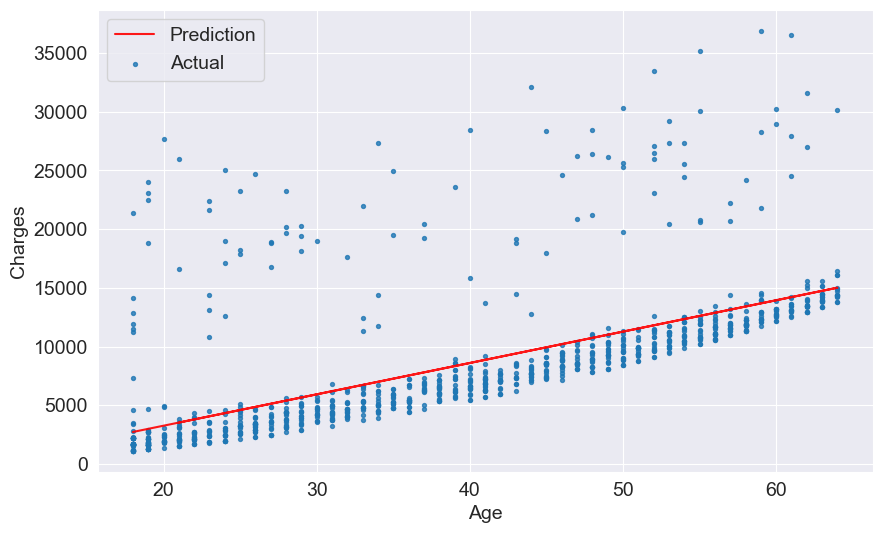

In [9]:

try_parameters(model.coef_, model.intercept_)


1. Create inputs and targets
2. then train the model
3. generate predictions
4. compue the loss to evalute the model

In [53]:
inputs, targets = non_smoker_df[["age"]], non_smoker_df["charges"]
model = LinearRegression().fit(inputs, targets)
predictions = model.predict(inputs)
loss = rmse(targets, predictions)
print("Loss :-", loss)

Loss :- 4662.505766636395


Linear Regression using Multiple Features

So far, we've used on the "age" feature to estimate "charges". Adding another feature like "bmi" is fairly straightforward. We simply assume the following relationship:

charges = w1 X age + w2 X bmi + b

We need to change just one line of code to include the BMI.

As you can see, adding the BMI doesn't seem to reduce the loss by much, as the BMI has a very weak correlation with charges, especially for non smokers.

In [17]:
non_smoker_df.charges.corr(non_smoker_df.bmi)

np.float64(0.08403654312833271)

In [54]:
fig = px.scatter_3d(non_smoker_df, x = "age", y = "bmi", z = "charges")
fig.update_traces(marker_size = 3, marker_opacity = 0.5)
fig.show()

As it was pretty fun to do it in 3d but in lardge numbers i cant read the data properly also lag issues can be there so thats why we need to make 2d plot

so before the loss is like 4668 lets make it as much as low possible

In [56]:
non_smoker_df.charges.corr(non_smoker_df.children)

np.float64(0.13892870453542197)

In [55]:
fig = px.strip(non_smoker_df, x = "children", y = "charges", title = "")
fig.update_traces(marker_size=4, marker_opacity=0.7)
fig.show()

now its like i got the correlation and the thing is now i need to make the model........

In [57]:
inputs, targets = non_smoker_df[["age", "bmi", "children"]], non_smoker_df["charges"]
model = LinearRegression().fit(inputs, targets)
predictions = model.predict(inputs)
loss = rmse(targets, predictions)
print("LOSS", loss)

LOSS 4608.470405038247


In [58]:
inputs, targets = medical_df[["age", "bmi", "children"]], medical_df["charges"]
model = LinearRegression().fit(inputs, targets)
predictions = model.predict(inputs)
loss = rmse(targets, predictions)
print("Loss", loss)

Loss 11355.317901125973


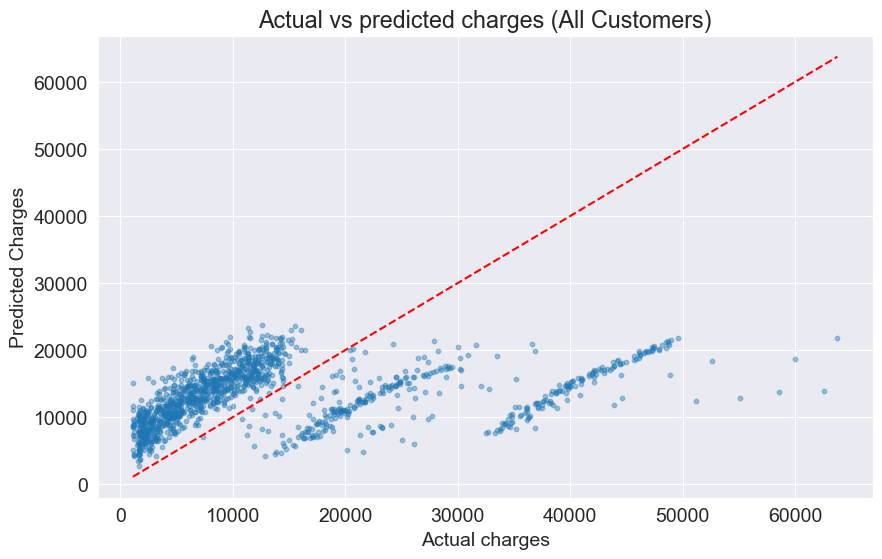

In [59]:
plt.Figure(figsize=(6,6))
plt.scatter(targets, predictions, alpha = 0.4, s = 10)
plt.xlabel("Actual charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs predicted charges (All Customers)")
plt.plot([targets.min(),  targets.max()],
         [targets.min(),  targets.max()],
           "r--")
plt.show()






<Axes: xlabel='smoker', ylabel='charges'>

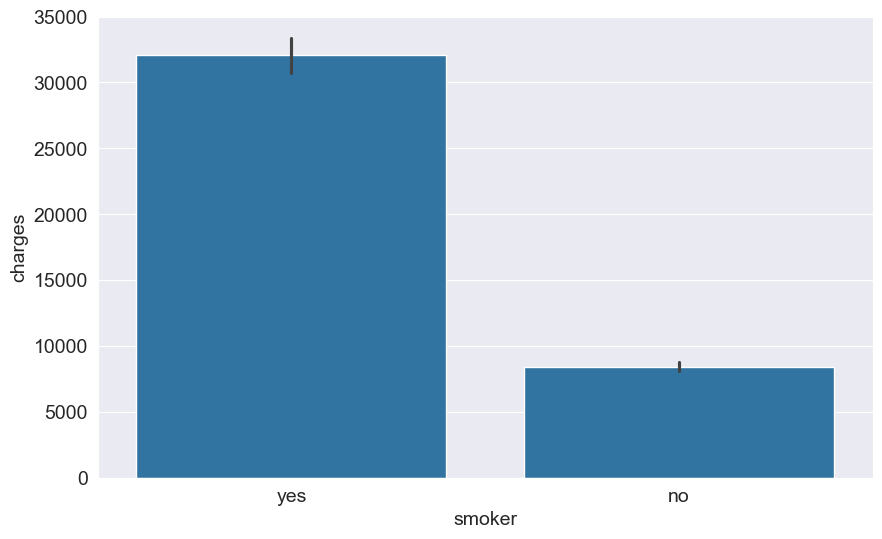

In [78]:
sns.barplot(data=medical_df, x= "smoker", y= "charges")

In [60]:
smoker_coodes = {'no': 0, "yes" : 1}
medical_df["smoker_code"] = medical_df.smoker.map(smoker_coodes)

In [61]:
medical_df.charges.corr(medical_df.smoker_code)

np.float64(0.7872514304984767)

In [62]:
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code
0,19,female,27.900,0,yes,southwest,16884.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0
1334,18,female,31.920,0,no,northeast,2205.98080,0
1335,18,female,36.850,0,no,southeast,1629.83350,0
1336,21,female,25.800,0,no,southwest,2007.94500,0


In [77]:
inputs, targets = medical_df[["age", "bmi", "children", "smoker_code"]], medical_df["charges"]
model = LinearRegression().fit(inputs, targets)
predictions = model.predict(inputs)
loss = rmse(targets, predictions)
print("Loss :", loss)

Loss : 6056.439217188081


<Axes: xlabel='sex', ylabel='charges'>

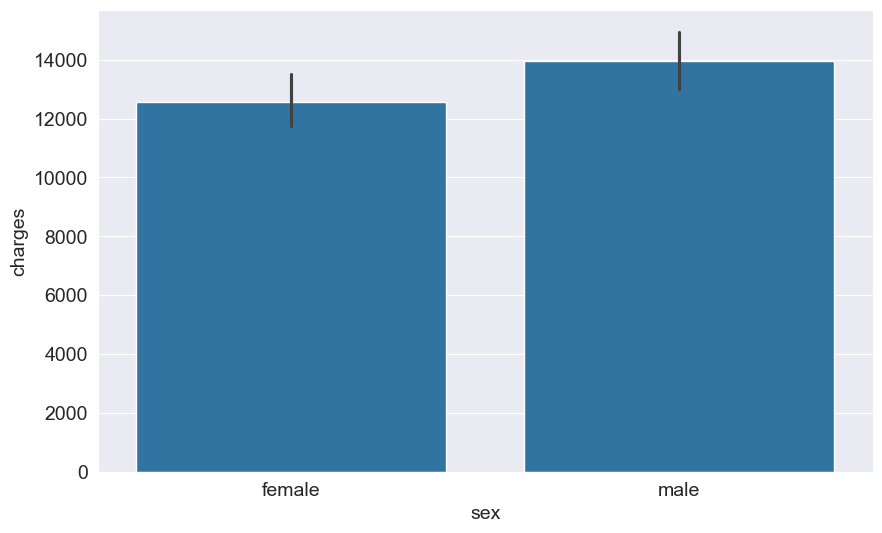

In [79]:
sns.barplot(data=medical_df, x = "sex", y = "charges")

In [80]:
sex__codes = {'female' : 0, "male" : 1}

In [81]:
medical_df["sex_code"] = medical_df.sex.map(sex__codes)

In [82]:
medical_df.charges.corr(medical_df.sex_code)

np.float64(0.057292062202025366)

In [83]:
inputs, targets = medical_df[["age", "bmi", "children", "smoker_code", "sex_code"]], medical_df["charges"]
model = LinearRegression().fit(inputs, targets)
predictions = model.predict(inputs)
loss = rmse(targets, predictions)
print("Loss :", loss)

Loss : 6056.100708754546


<Axes: xlabel='region', ylabel='charges'>

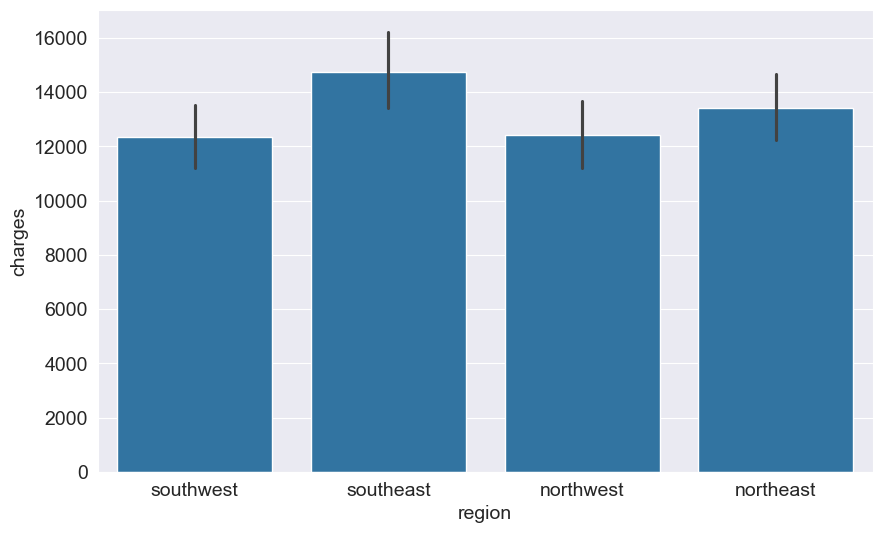

In [84]:
sns.barplot(data=medical_df, x= "region", y= "charges")

In [85]:
from sklearn import preprocessing
enc = preprocessing.OneHotEncoder()
enc.fit(medical_df[["region"]])
enc.categories_

[array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [86]:
one_hot = enc.transform(medical_df[["region"]]).toarray()
one_hot

array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.]])

In [33]:
medical_df[["northeast", "northwest", "southeast", "southwest"]] = one_hot
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,1,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,1,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,0,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0,0.0,0.0,1.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0,0.0,0.0,0.0,1.0


In [35]:
# Create inputs and targets
input_cols = ['age', 'bmi', 'children', 'smoker_code', 'sex_code', 'northeast', 'northwest', 'southeast', 'southwest']
inputs, targets = medical_df[input_cols], medical_df['charges']

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute loss to evalute the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 6041.6796511744515


Model Improvements
Let's discuss and apply some more improvements to our model.

Feature Scaling
Recall that due to regulatory requirements, we also need to explain the rationale behind the predictions our model.


To compare the importance of each feature in the model, our first instinct might be to compare their weights.

In [36]:
model.coef_

array([  256.85635254,   339.19345361,   475.50054515, 23848.53454191,
        -131.3143594 ,   587.00923503,   234.0453356 ,  -448.01281436,
        -373.04175627])

In [37]:
model.intercept_

np.float64(-12525.547811195444)

In [38]:
weights_df = pd.DataFrame({
    "feature" : np.append(input_cols, 1),
    "weight" : np.append(model.coef_, model.intercept_)})
weights_df

,feature,weight
0,age,256.856353
1,bmi,339.193454
2,children,475.500545
3,smoker_code,23848.534542
4,sex_code,-131.314359
5,northeast,587.009235
6,northwest,234.045336
7,southeast,-448.012814
8,southwest,-373.041756
9,1,-12525.547811


In [39]:
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,1,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,1,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,0,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0,0.0,0.0,1.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0,0.0,0.0,0.0,1.0


In [72]:
from sklearn.preprocessing import StandardScaler
numeric_cols = ["age", "bmi", 'children']
scaler = StandardScaler()
scaler.fit(medical_df[numeric_cols])
scaler.mean_

array([39.20702541, 30.66339686,  1.09491779])

In [73]:
scaler.var_

array([197.25385199,  37.16008997,   1.45212664])

In [74]:
scaled_inputs = scaler.transform(medical_df[numeric_cols])
scaled_inputs

array([[-1.43876426, -0.45332   , -0.90861367],
       [-1.50996545,  0.5096211 , -0.07876719],
       [-0.79795355,  0.38330685,  1.58092576],
       ...,
       [-1.50996545,  1.0148781 , -0.90861367],
       [-1.29636188, -0.79781341, -0.90861367],
       [ 1.55168573, -0.26138796, -0.90861367]])

These can now we combined with the categorical data

In [88]:
from sklearn import preprocessing

enc = preprocessing.OneHotEncoder()
enc.fit(medical_df[['region']])

one_hot = enc.transform(medical_df[['region']]).toarray()

medical_df[['northeast', 'northwest', 'southeast', 'southwest']] = one_hot


In [68]:
medical_df["smoker_code"] = medical_df.smoker.map({"no": 0, "yes": 1})
medical_df["sex_code"] = medical_df.sex.map({"female": 0, "male": 1})


In [89]:
cat_cols = ["smoker_code", "sex_code", "northeast", "northwest", "southeast", "southwest"]
categorical_data = medical_df[cat_cols].values


In [90]:
inputs = np.concatenate((scaled_inputs, categorical_data), axis=1)
targets = medical_df.charges

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute loss to evalute the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 6041.6796511744515


In [92]:
weights_df = pd.DataFrame({
    "feature" : np.append(numeric_cols + cat_cols, 1),
    "weight" : np.append(model.coef_, model.intercept_)})
weights_df.sort_values("weight", ascending= False)

,feature,weight
3,smoker_code,23848.534542
9,1,8466.483215
0,age,3607.472736
1,bmi,2067.691966
5,northeast,587.009235
2,children,572.998210
6,northwest,234.045336
4,sex_code,-131.314359
8,southwest,-373.041756
7,southeast,-448.012814


As you can see now, the most important feature are:

1. Smoker
2. Age
3. BMI

In [148]:
from sklearn.model_selection import train_test_split
inputs_train, inputs_test, targets_train, targets_test = train_test_split(inputs, targets, test_size=0.1)
model = LinearRegression().fit(inputs_train, targets_train)
predictions_test = model.predict(inputs_test)
loss = rmse(targets_test, predictions_test)
print("Test Loss" ,  loss)

Test Loss 5624.901351657333


In [111]:
predictions_training = model.predict(inputs_train)
loss = rmse(targets_train, predictions_training)
print("Training Loss", loss)

Training Loss 6148.567708868544
